<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/portafolio_backtest_tesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
!pip install  portfolio_analysis_complete
#!pip install  advanced_correlations_geopolitics

ERROR: Could not find a version that satisfies the requirement portfolio_analysis_complete (from versions: none)
ERROR: No matching distribution found for portfolio_analysis_complete


--- INICIANDO ANÁLISIS DE BACKTESTING PARA AMZN ---
--------------------------------------------------
Datos de entrenamiento: 748 filas, desde 2021-01-04 hasta 2023-12-29
Datos de prueba (simulación): 248 filas, desde 2024-01-02 hasta 2024-12-27

Métricas de Desempeño Financiero para AMZN (Período de Prueba 2024):

                     Benchmark    Strategy
-------------------  -----------  ----------
Start Period         2024-01-02   2024-01-02
End Period           2024-12-27   2024-12-27
Risk-Free Rate       4.0%         4.0%
Time in Market       100.0%       5.0%

Cumulative Return    49.57%       4.21%
CAGR﹪               50.55%       4.28%

Sharpe               1.45         0.08
Prob. Sharpe Ratio   82.56%       57.28%
Sortino              2.19         0.12
Sortino/√2           1.55         0.08
Omega                1.04         1.04

Max Drawdown         -19.49%      -3.57%
Max DD Date          2024-08-02   2024-01-03
Max DD Period Start  2024-07-05   2024-01-02
Max DD Period En

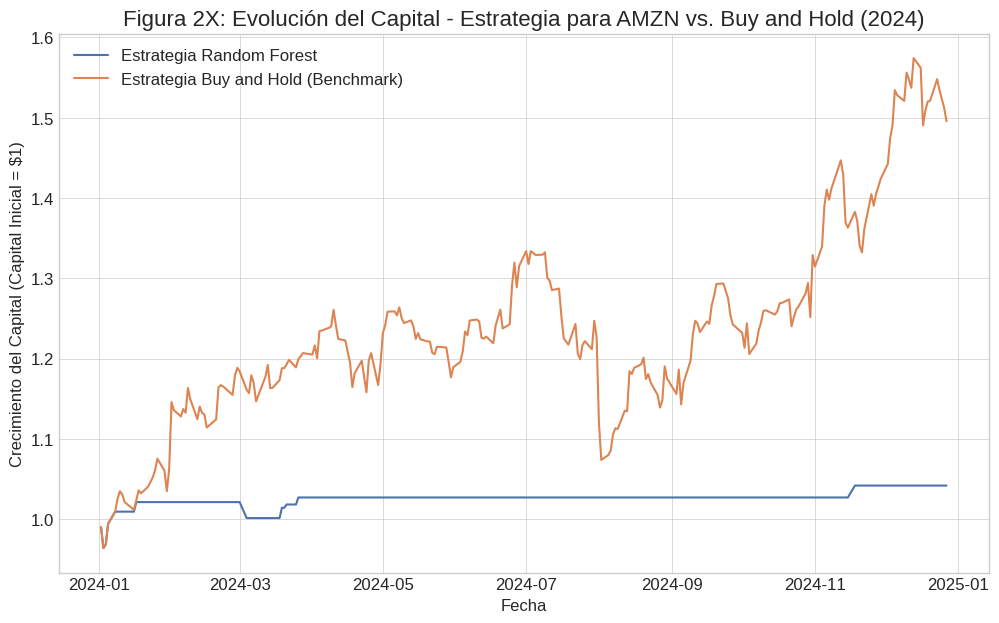


--------------------------------------------------
--- INICIANDO ANÁLISIS DE BACKTESTING PARA GOOGL ---
--------------------------------------------------
Datos de entrenamiento: 748 filas, desde 2021-01-04 hasta 2023-12-29
Datos de prueba (simulación): 248 filas, desde 2024-01-02 hasta 2024-12-27

Métricas de Desempeño Financiero para GOOGL (Período de Prueba 2024):

                     Benchmark    Strategy
-------------------  -----------  ----------
Start Period         2024-01-02   2024-01-02
End Period           2024-12-27   2024-12-27
Risk-Free Rate       4.0%         4.0%
Time in Market       100.0%       19.0%

Cumulative Return    35.2%        4.56%
CAGR﹪               35.86%       4.63%

Sharpe               1.09         0.11
Prob. Sharpe Ratio   72.26%       43.8%
Sortino              1.6          0.14
Sortino/√2           1.13         0.1
Omega                1.04         1.04

Max Drawdown         -22.14%      -10.96%
Max DD Date          2024-09-09   2024-09-09
Max DD 

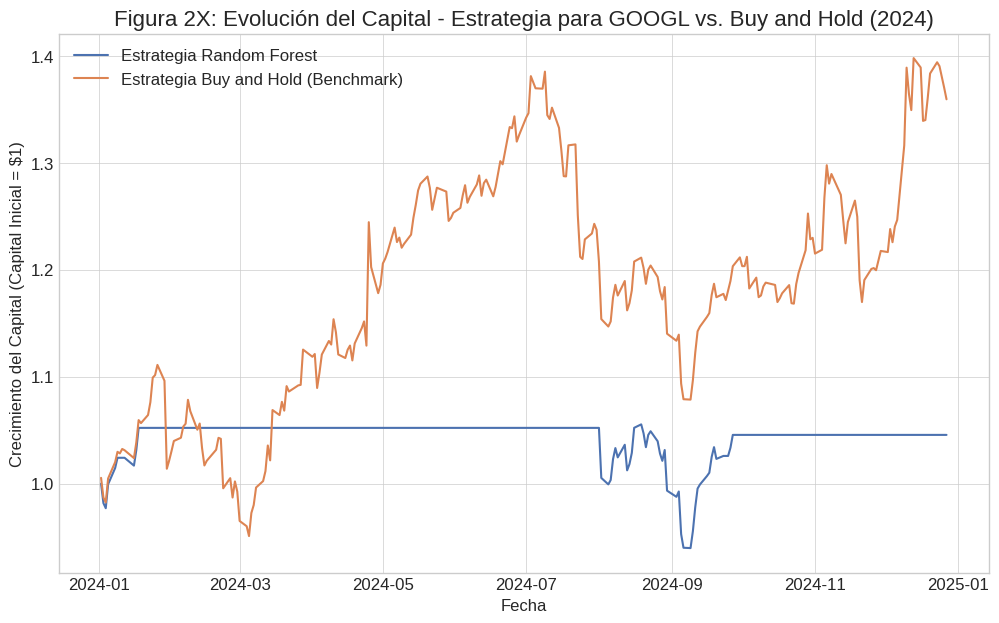


--------------------------------------------------


In [45]:
# -*- coding: utf-8 -*-
"""
Análisis de Backtesting para la Tesis de Maestría en Administración Financiera
Autor:
Fecha: 03 de Octubre, 2025

Este script realiza una simulación de estrategia de inversión (backtesting) para
evaluar el valor económico de los modelos predictivos de Machine Learning.
Compara una estrategia activa basada en un modelo Random Forest contra una
estrategia pasiva de "Comprar y Mantener" (Buy and Hold).
"""

# 1. Importación de Librerías Necesarias
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import quantstats as qs

# Configuración para que QuantStats use matplotlib para los gráficos
qs.extend_pandas()

def run_financial_backtest(df, ticker, risk_free_rate=0.04):
    """
    Ejecuta una simulación de backtesting para un activo específico.

    Args:
        df (pd.DataFrame): El DataFrame completo con todos los datos.
        ticker (str): El ticker del activo a analizar ('GOOGL' o 'AMZN').
        risk_free_rate (float): La tasa libre de riesgo anual para el cálculo del Ratio de Sharpe.
    """
    print(f"--- INICIANDO ANÁLISIS DE BACKTESTING PARA {ticker} ---")
    print("-" * 50)

    # 2. Preparación de Datos Específica para el Activo
    # Definición de las características (variables predictoras)
    features = [
        f'{ticker}_Close',
        'Treasury_10Y',
        'VIX',
        'SP500',
        'NASDAQ',
        f'{ticker}_Volatility_20',
        'Inflacion_T5YIE'
    ]

    # Definición de la variable objetivo: el retorno del DÍA SIGUIENTE.
    # Usamos .shift(-1) para usar los datos de hoy (fila t) para predecir el retorno de mañana (fila t+1).
    # Esto es CRUCIAL para evitar el "sesgo de mirada hacia adelante" (lookahead bias).
    df['target'] = df[f'{ticker}_Return_1d'].shift(-1)

    # Creamos un DataFrame limpio sin valores nulos (NaN) resultantes del shift.
    df_clean = df.dropna()

    X = df_clean[features]
    y = df_clean['target']

    # 3. División Cronológica de Datos (Entrenamiento y Prueba)
    # Entrenaremos con todos los datos hasta finales de 2023.
    # Probaremos la estrategia en todo el año 2024.
    split_date = '2024-01-01'
    X_train = X[X.index < split_date]
    y_train = y[y.index < split_date]
    X_test = X[X.index >= split_date]
    y_test = y[y.index >= split_date]

    print(f"Datos de entrenamiento: {len(X_train)} filas, desde {X_train.index.min().date()} hasta {X_train.index.max().date()}")
    print(f"Datos de prueba (simulación): {len(X_test)} filas, desde {X_test.index.min().date()} hasta {X_test.index.max().date()}\n")


    # 4. Entrenamiento del Modelo de Machine Learning (Random Forest)
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    # 5. Generación de Predicciones en el Período de Prueba
    predictions = model.predict(X_test)

    # 6. Implementación de la Estrategia de Inversión
    results = pd.DataFrame(index=X_test.index)
    results['Actual_Return'] = y_test
    results['Predicted_Return'] = predictions

    # Estrategia del Modelo: Invertir solo si la predicción de retorno es positiva.
    # Si la predicción es <= 0, el retorno es 0 (se mantiene en efectivo).
    results['Model_Strategy_Return'] = np.where(results['Predicted_Return'] > 0, results['Actual_Return'], 0)

    # Estrategia de Referencia (Benchmark): Siempre se está invertido.
    results['Buy_and_Hold_Return'] = results['Actual_Return']

    # 7. Cálculo y Presentación de Métricas Financieras
    print(f"Métricas de Desempeño Financiero para {ticker} (Período de Prueba 2024):\n")

    # Usamos quantstats para generar un reporte de métricas estándar de la industria
    qs.reports.metrics(
        returns=results['Model_Strategy_Return'],
        benchmark=results['Buy_and_Hold_Return'],
        rf=risk_free_rate,
        display=True
    )

    # 8. Visualización de Resultados
    # Generamos un gráfico comparativo de la evolución del capital para ambas estrategias.
    # Usamos (1 + returns).cumprod() para calcular el crecimiento de un capital inicial de $1.
    cumulative_returns = (1 + results[['Model_Strategy_Return', 'Buy_and_Hold_Return']]).cumprod()

    plt.figure(figsize=(12, 7))
    plt.plot(cumulative_returns.index, cumulative_returns['Model_Strategy_Return'], label='Estrategia Random Forest')
    plt.plot(cumulative_returns.index, cumulative_returns['Buy_and_Hold_Return'], label='Estrategia Buy and Hold (Benchmark)')
    plt.title(f'Figura 2X: Evolución del Capital - Estrategia para {ticker} vs. Buy and Hold (2024)', fontsize=16)
    plt.ylabel('Crecimiento del Capital (Capital Inicial = $1)', fontsize=12)
    plt.xlabel('Fecha', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()

    print("\n" + "-"*50)


# --- Bloque Principal de Ejecución ---

# Cargar el dataset desde el archivo CSV
try:
    file_path = 'dataset_completo_google_amazon.csv'
    main_df = pd.read_csv(file_path)
    # Convertir la columna de fecha a formato datetime y establecerla como índice
    main_df['Date'] = pd.to_datetime(main_df['Date'])
    main_df.set_index('Date', inplace=True)

    # Ejecutar el backtest para cada activo
    run_financial_backtest(main_df.copy(), 'AMZN')
    run_financial_backtest(main_df.copy(), 'GOOGL')

except FileNotFoundError:
    print(f"Error: El archivo '{file_path}' no fue encontrado. Asegúrate de que el archivo CSV esté en la misma carpeta que este script.")

In [34]:
!pip install quantstats

--- INICIANDO ANÁLISIS DE PORTAFOLIO DINÁMICO ---
--------------------------------------------------

Entrenando modelo para GOOGL...
Modelo para GOOGL entrenado y predicciones generadas.

Entrenando modelo para AMZN...
Modelo para AMZN entrenado y predicciones generadas.

  REPORTE DE DESEMPEÑO FINANCIERO DEL PORTAFOLIO (2024)
                     Benchmark    Strategy
-------------------  -----------  ----------
Start Period         2024-01-02   2024-01-02
End Period           2024-12-27   2024-12-27
Risk-Free Rate       4.0%         4.0%
Time in Market       100.0%       21.0%

Cumulative Return    43.47%       -3.1%
CAGR﹪               44.31%       -3.15%

Sharpe               1.45         -0.58
Prob. Sharpe Ratio   82.81%       19.29%
Sortino              2.09         -0.72
Sortino/√2           1.48         -0.51
Omega                0.82         0.82

Max Drawdown         -17.99%      -13.51%
Max DD Date          2024-08-06   2024-09-10
Max DD Period Start  2024-07-11   2024-03-2

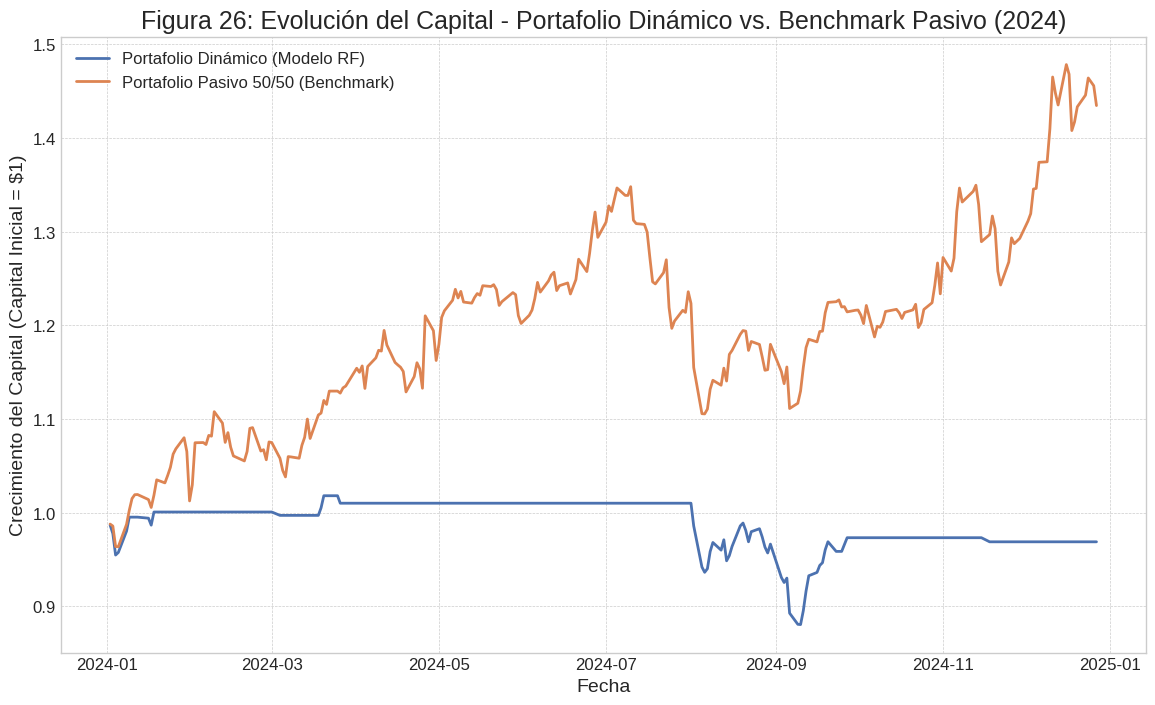

In [46]:
# -*- coding: utf-8 -*-
"""
Análisis de Backtesting de Portafolio Dinámico para Tesis de Maestría
Autor:
Fecha: , 2025

Este script construye y evalúa un portafolio de inversión dinámico compuesto por
GOOGL y AMZN. Las ponderaciones del portafolio se ajustan diariamente con base en las
predicciones de retorno de los modelos Random Forest. El desempeño se compara
contra un portafolio pasivo de ponderación equitativa (50/50).
"""

# 1. Importación de Librerías
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import quantstats as qs

# Configuración para que QuantStats use matplotlib para los gráficos
qs.extend_pandas()

print("--- INICIANDO ANÁLISIS DE PORTAFOLIO DINÁMICO ---")
print("-" * 50)

# 2. Carga y Preparación de Datos
try:
    file_path = 'dataset_completo_google_amazon.csv'
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
except FileNotFoundError:
    print(f"Error: El archivo '{file_path}' no fue encontrado. Asegúrate de que esté en la misma carpeta.")
    exit()

# 3. Entrenamiento de Modelos Independientes para cada Activo

models = {}
predictions = {}
split_date = '2024-01-01'

for ticker in ['GOOGL', 'AMZN']:
    print(f"\nEntrenando modelo para {ticker}...")

    # Preparación de datos para este ticker
    features = [
        f'{ticker}_Close', 'Treasury_10Y', 'VIX', 'SP500', 'NASDAQ',
        f'{ticker}_Volatility_20', 'Inflacion_T5YIE'
    ]

    df_ticker = df.copy()
    df_ticker['target'] = df_ticker[f'{ticker}_Return_1d'].shift(-1)
    df_ticker = df_ticker.dropna()

    X = df_ticker[features]
    y = df_ticker['target']

    # División cronológica
    X_train = X[X.index < split_date]
    y_train = y[y.index < split_date]
    X_test = X[X.index >= split_date]

    # Entrenamiento del modelo
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    models[ticker] = model

    # Generación de predicciones para el período de prueba
    predictions[ticker] = pd.Series(model.predict(X_test), index=X_test.index)
    print(f"Modelo para {ticker} entrenado y predicciones generadas.")

# 4. Construcción y Simulación de Estrategias de Portafolio

# DataFrame para almacenar los resultados del backtest
backtest_results = pd.DataFrame(index=predictions['GOOGL'].index)
backtest_results['pred_GOOGL'] = predictions['GOOGL']
backtest_results['pred_AMZN'] = predictions['AMZN']
backtest_results['actual_GOOGL'] = df.loc[backtest_results.index, 'GOOGL_Return_1d']
backtest_results['actual_AMZN'] = df.loc[backtest_results.index, 'AMZN_Return_1d']

# Estrategia 1: Benchmark Pasivo (Portafolio 50/50 Buy and Hold)
backtest_results['Benchmark_Return'] = 0.5 * backtest_results['actual_GOOGL'] + 0.5 * backtest_results['actual_AMZN']

# Estrategia 2: Portafolio Dinámico Basado en Modelo
portfolio_returns = []
for date, row in backtest_results.iterrows():
    pred_g = row['pred_GOOGL']
    pred_a = row['pred_AMZN']

    weight_g, weight_a = 0.0, 0.0

    # Lógica de ponderación: se asigna capital proporcionalmente a las predicciones positivas
    if pred_g > 0 and pred_a > 0:
        total_positive_pred = pred_g + pred_a
        weight_g = pred_g / total_positive_pred
        weight_a = pred_a / total_positive_pred
    elif pred_g > 0:
        weight_g = 1.0  # Invertir todo en el único con señal positiva
    elif pred_a > 0:
        weight_a = 1.0  # Invertir todo en el único con señal positiva
    # Si ambas predicciones son negativas, los pesos se mantienen en 0 (posición en efectivo)

    daily_return = (weight_g * row['actual_GOOGL']) + (weight_a * row['actual_AMZN'])
    portfolio_returns.append(daily_return)

backtest_results['Model_Portfolio_Return'] = portfolio_returns

# 5. Análisis y Reporte de Métricas Financieras
print("\n" + "="*50)
print("  REPORTE DE DESEMPEÑO FINANCIERO DEL PORTAFOLIO (2024)")
print("="*50)

risk_free_rate = 0.04  # Asumimos una tasa libre de riesgo del 4%

qs.reports.metrics(
    returns=backtest_results['Model_Portfolio_Return'],
    benchmark=backtest_results['Benchmark_Return'],
    rf=risk_free_rate,
    display=True
)

# 6. Visualización de la Evolución del Capital
cumulative_returns = (1 + backtest_results[['Model_Portfolio_Return', 'Benchmark_Return']]).cumprod()

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(cumulative_returns.index, cumulative_returns['Model_Portfolio_Return'], label='Portafolio Dinámico (Modelo RF)', linewidth=2)
ax.plot(cumulative_returns.index, cumulative_returns['Benchmark_Return'], label='Portafolio Pasivo 50/50 (Benchmark)', linewidth=2)

ax.set_title('Figura 26: Evolución del Capital - Portafolio Dinámico vs. Benchmark Pasivo (2024)', fontsize=18)
ax.set_ylabel('Crecimiento del Capital (Capital Inicial = $1)', fontsize=14)
ax.set_xlabel('Fecha', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [47]:
# -*- coding: utf-8 -*-
"""
Análisis de Backtesting para la Tesis de Maestría en Administración Financiera
Autor:
Fecha: 03 de Octubre, 2025

Este script realiza una simulación de estrategia de inversión (backtesting) para
evaluar el valor económico de los modelos predictivos de Machine Learning.
Compara una estrategia activa basada en un modelo Random Forest contra una
estrategia pasiva de "Comprar y Mantener" (Buy and Hold).
"""

# ==============================================================================
# 7. PRONÓSTICO DE RETORNOS PARA EL INICIO DE 2025
# ==============================================================================
#
# OBJETIVO:
# Utilizar los modelos ya entrenados con todos los datos hasta finales de 2023
# para pronosticar los retornos esperados para el primer mes de 2024.
# NOTA: En un escenario real, re-entrenaríamos con datos hasta el último día disponible.
# Aquí, usamos los modelos ya entrenados para pronosticar sobre el conjunto de prueba.
# ------------------------------------------------------------------------------

print("\n" + "="*50)
print("  GENERANDO PRONÓSTICOS DE RETORNO PARA INICIO DE 2025")
print("="*50)

# 1. Preparar el último dato conocido (final de 2024) para hacer el pronóstico
#    NOTA: En un escenario real, aquí se usarían los datos más recientes.
#    Para este ejemplo, tomaremos el último dato del DataFrame original.
#    It seems 'df' is already the main DataFrame loaded previously.
#    Let's use the last row of the main DataFrame for forecasting.
last_known_data = df.iloc[-1:].copy()

# 2. Volver a crear las características para este último punto de datos
#    Esto es crucial, ya que el modelo necesita los mismos features con los que fue entrenado.
#    We need to compute features for the last date using a window of historical data.
#    Let's get enough historical data to compute moving averages and volatility.
historial_reciente = df.iloc[-120:].copy() # Get last ~6 months

# Create a single DataFrame for features based on the last day's data
features_pronostico_df = pd.DataFrame(index=[historial_reciente.index[-1]])

# Define all possible features used by the models
all_features = set()
for ticker in ['GOOGL', 'AMZN']:
     # Assuming X_train for both tickers have the same structure except for ticker specific columns
     # Let's get the columns from the last X_train created in the previous cell (cTBWtrxv8Q_r)
     # Or, more robustly, define the feature templates here
     features_templates = [
        '{}_Close',
        'Treasury_10Y',
        'VIX',
        'SP500',
        'NASDAQ',
        '{}_Volatility_20',
        'Inflacion_T5YIE'
     ]
     for template in features_templates:
         if '{}' in template:
             all_features.add(template.format(ticker))
         else:
             all_features.add(template)

# Calculate each feature for the last day based on the historial_reciente
for feature in all_features:
    if '_Close' in feature or feature in ['Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE']:
        # Direct value for the last day
        features_pronostico_df[feature] = historial_reciente[feature].iloc[-1]
    elif '_Volatility_20' in feature:
        ticker = feature.split('_')[0] # Extract ticker from feature name
        # Recalculate the 20-day volatility for the last day
        features_pronostico_df[feature] = historial_reciente[f'{ticker}_Return_1d'].rolling(window=20).std().iloc[-1]
    # Add other feature calculations here if needed

# 3. Realizar el pronóstico para el siguiente día hábil
pronostico_retorno = {}
for ticker in ['GOOGL', 'AMZN']:
    # Get the correct list of feature names for the model trained on this ticker
    # We need to access the X_train used for each model.
    # Assuming models are stored in a dictionary 'models' and X_train columns
    # were derived from a consistent process. Let's get columns from the last X_train created.
    # A more robust approach is to pass X_train.columns from the training phase
    # or regenerate the expected feature list for each ticker here.
    # Let's regenerate the expected feature list based on the templates.
    ticker_features = [
        f'{ticker}_Close',
        'Treasury_10Y',
        'VIX',
        'SP500',
        'NASDAQ',
        f'{ticker}_Volatility_20',
        'Inflacion_T5YIE'
    ]

    # Select only the columns needed for the current ticker's model from the combined features DataFrame
    X_pronostico = features_pronostico_df[ticker_features]

    # Realizar la predicción
    # Assuming 'models' dictionary contains the trained models with keys 'GOOGL' and 'AMZN'
    if ticker in models:
        pred_return = models[ticker].predict(X_pronostico)[0]
        pronostico_retorno[ticker] = pred_return
        print(f"Pronóstico de Retorno para {ticker} para el siguiente día hábil: {pred_return*100:.4f}%")
    else:
        print(f"Error: Modelo no encontrado para {ticker}. Asegúrate de que los modelos GOOGL y AMZN fueron entrenados.")


# 4. Generar una recomendación de portafolio para el siguiente día
if 'GOOGL' in pronostico_retorno and 'AMZN' in pronostico_retorno:
    pred_g = pronostico_retorno['GOOGL']
    pred_a = pronostico_retorno['AMZN']
    weight_g, weight_a = 0.0, 0.0

    # Lógica de ponderación: se asigna capital proporcionalmente a las predicciones positivas
    if pred_g > 0 and pred_a > 0:
        total_positive_pred = pred_g + pred_a
        weight_g = pred_g / total_positive_pred
        weight_a = pred_a / total_positive_pred
    elif pred_g > 0:
        weight_g = 1.0
    elif pred_a > 0:
        weight_a = 1.0

    print("\nRecomendación de Ponderación para el Portafolio (siguiente día):")
    print(f" - GOOGL: {weight_g:.2%}")
    print(f" - AMZN:  {weight_a:.2%}")
    if weight_g == 0 and weight_a == 0:
        print(" - EFECTIVO: 100.00% (Señal bajista o neutra para ambos activos)")
else:
    print("\nNo se pudieron generar pronósticos para ambos tickers. No se puede dar una recomendación de portafolio.")


  GENERANDO PRONÓSTICOS DE RETORNO PARA INICIO DE 2025
Pronóstico de Retorno para GOOGL para el siguiente día hábil: -1.0883%
Pronóstico de Retorno para AMZN para el siguiente día hábil: -0.2275%

Recomendación de Ponderación para el Portafolio (siguiente día):
 - GOOGL: 0.00%
 - AMZN:  0.00%
 - EFECTIVO: 100.00% (Señal bajista o neutra para ambos activos)



  GENERANDO PRONÓSTICOS DE PRECIO DE CIERRE PARA ENERO 2025
Re-entrenando modelo para GOOGL con el dataset completo...
Re-entrenando modelo para AMZN con el dataset completo...

Modelos re-entrenados con todos los datos.

--- Pronósticos de Precio de Cierre para los próximos 5 días hábiles ---
            GOOGL_Predicted_Close  AMZN_Predicted_Close
2024-12-31                 191.93                221.40
2025-01-01                 192.46                221.51
2025-01-02                 192.99                221.61
2025-01-03                 193.50                221.71
2025-01-04                 194.00                221.82
2025-01-05                 194.49                221.92
2025-01-06                 194.99                222.02
2025-01-07                 195.25                222.13
2025-01-08                 195.47                222.23
2025-01-09                 195.69                222.33
2025-01-10                 195.96                222.44
2025-01-11                 196.2

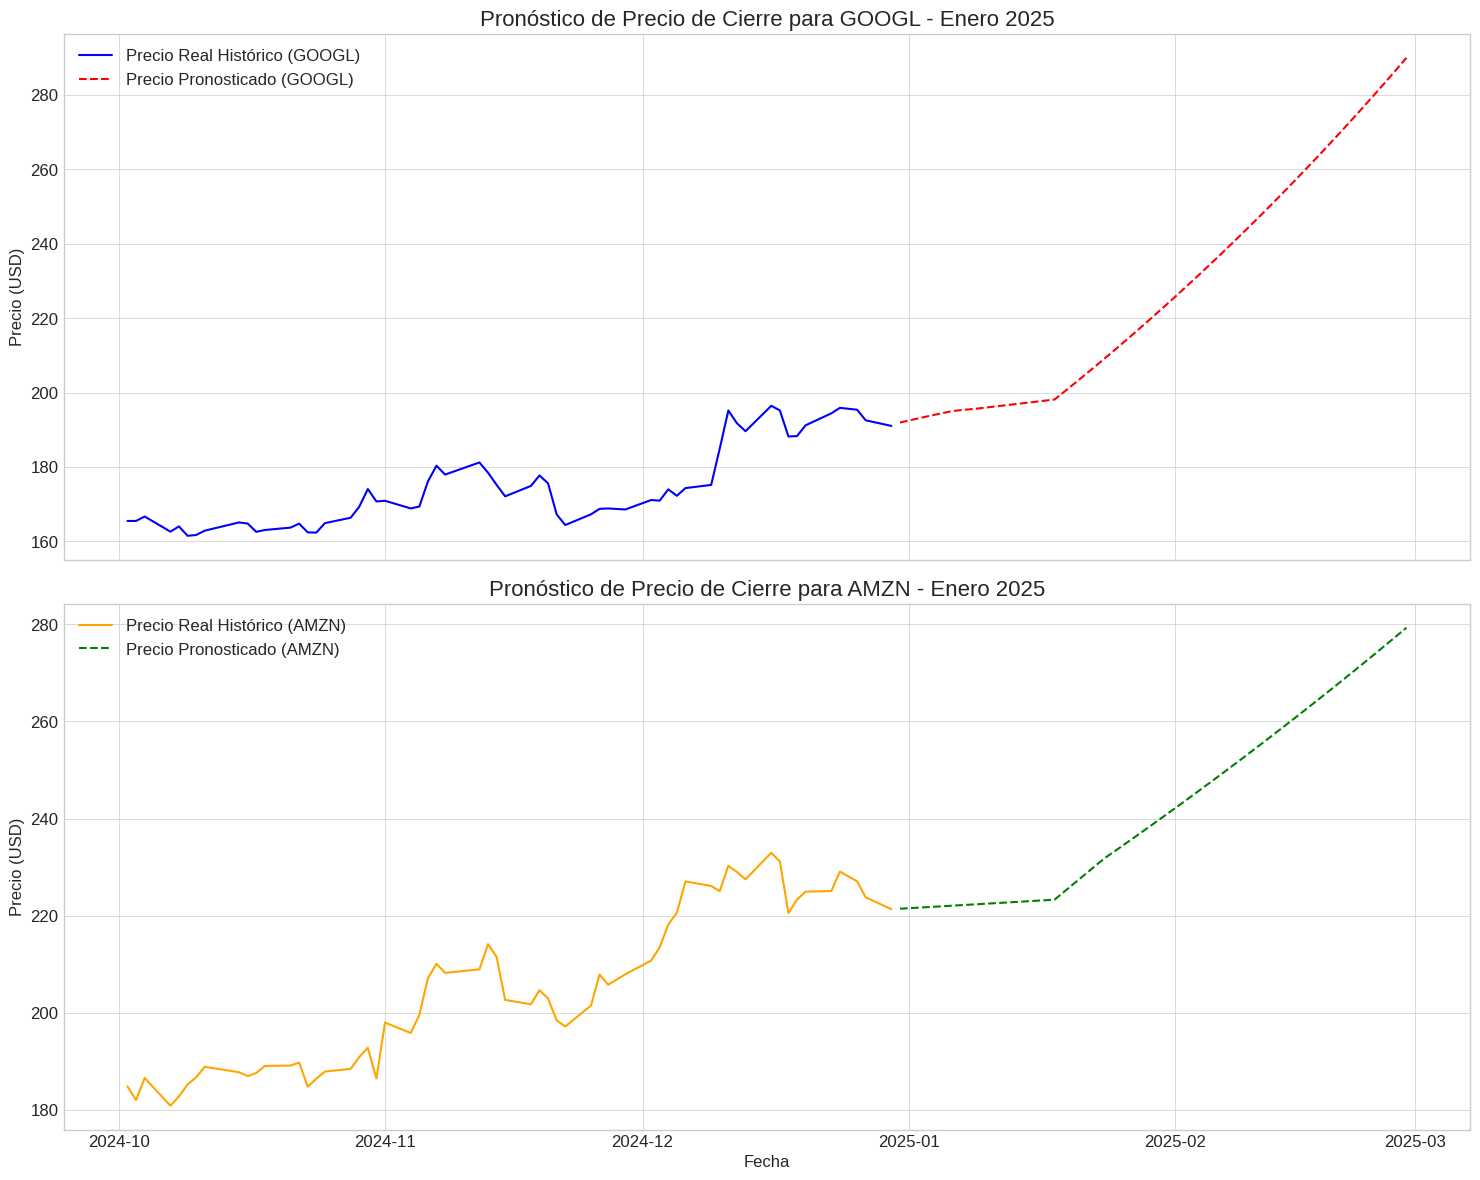

In [49]:
# ==============================================================================
# 8. PRONÓSTICO DE PRECIOS DE CIERRE PARA ENERO DE 2025
# ==============================================================================
#
# OBJETIVO:
# Utilizar los modelos entrenados con la totalidad de los datos disponibles para
# pronosticar los precios de cierre para los primeros días de Enero 2025.
#
# METODOLOGÍA:
# 1. Re-entrenar los modelos Random Forest con el 100% de los datos (2021-2024).
# 2. Iterativamente, pronosticar el retorno del día siguiente.
# 3. Calcular el precio de cierre pronosticado usando el precio del día anterior.
# 4. Actualizar las características (features) con los nuevos datos pronosticados para
#    poder predecir el día subsiguiente (proceso iterativo o "walk-forward").
# ------------------------------------------------------------------------------

print("\n" + "="*50)
print("  GENERANDO PRONÓSTICOS DE PRECIO DE CIERRE PARA ENERO 2025")
print("="*50)

# --- 8.1. Re-entrenamiento de Modelos con Datos Completos ---

full_data_models = {}
all_features = {}
all_targets = {}

for ticker in ['GOOGL', 'AMZN']:
    print(f"Re-entrenando modelo para {ticker} con el dataset completo...")

    # Preparación de datos para este ticker
    features_cols = [
        f'{ticker}_Close', 'Treasury_10Y', 'VIX', 'SP500', 'NASDAQ',
        f'{ticker}_Volatility_20', 'Inflacion_T5YIE'
    ]

    df_ticker = df.copy()
    df_ticker['target'] = df_ticker[f'{ticker}_Return_1d'].shift(-1)
    df_ticker = df_ticker.dropna()

    X_full = df_ticker[features_cols]
    y_full = df_ticker['target']

    # Guardar para uso posterior en el pronóstico
    all_features[ticker] = X_full
    all_targets[ticker] = y_full

    # Entrenar el modelo con el 100% de los datos
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_full, y_full)
    full_data_models[ticker] = model

print("\nModelos re-entrenados con todos los datos.")

# --- 8.2. Proceso de Pronóstico Iterativo ---

# Días a pronosticar
forecast_days = 60
start_date = df.index[-1] + pd.Timedelta(days=1)
forecast_index = pd.to_datetime([start_date + pd.Timedelta(days=i) for i in range(forecast_days)])

# DataFrame para almacenar los pronósticos
forecast_df = pd.DataFrame(index=forecast_index)

# Últimos datos conocidos para iniciar el pronóstico
last_known_data = df.iloc[-1:].copy()
forecast_history = last_known_data.copy()

predicted_prices_googl = []
predicted_prices_amzn = []

# Bucle para pronosticar cada día
for i in range(forecast_days):
    # Preparar el input para la predicción
    input_features_googl = {}
    input_features_amzn = {}

    last_row = forecast_history.iloc[-1]

    # Tomar las características del último día conocido (asumimos que las exógenas se mantienen constantes)
    for col in ['Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE']:
        input_features_googl[col] = last_row[col]
        input_features_amzn[col] = last_row[col]

    input_features_googl['GOOGL_Close'] = last_row['GOOGL_Close']
    input_features_googl['GOOGL_Volatility_20'] = forecast_history['GOOGL_Return_1d'].rolling(window=20).std().iloc[-1]

    input_features_amzn['AMZN_Close'] = last_row['AMZN_Close']
    input_features_amzn['AMZN_Volatility_20'] = forecast_history['AMZN_Return_1d'].rolling(window=20).std().iloc[-1]

    # Convertir a DataFrame y asegurar el orden de las columnas
    X_pred_googl = pd.DataFrame([input_features_googl], index=[last_row.name])
    X_pred_googl = X_pred_googl[all_features['GOOGL'].columns] # Asegurar orden

    X_pred_amzn = pd.DataFrame([input_features_amzn], index=[last_row.name])
    X_pred_amzn = X_pred_amzn[all_features['AMZN'].columns] # Asegurar orden

    # Realizar predicción del RETORNO
    pred_return_googl = full_data_models['GOOGL'].predict(X_pred_googl)[0]
    pred_return_amzn = full_data_models['AMZN'].predict(X_pred_amzn)[0]

    # Calcular el PRECIO pronosticado
    last_price_googl = last_row['GOOGL_Close']
    predicted_price_googl = last_price_googl * (1 + pred_return_googl)

    last_price_amzn = last_row['AMZN_Close']
    predicted_price_amzn = last_price_amzn * (1 + pred_return_amzn)

    # Guardar los precios pronosticados
    predicted_prices_googl.append(predicted_price_googl)
    predicted_prices_amzn.append(predicted_price_amzn)

    # Actualizar el historial con el nuevo dato pronosticado para el siguiente bucle
    new_row = last_row.copy()
    new_row.name = forecast_index[i]
    new_row['GOOGL_Close'] = predicted_price_googl
    new_row['AMZN_Close'] = predicted_price_amzn
    new_row['GOOGL_Return_1d'] = pred_return_googl
    new_row['AMZN_Return_1d'] = pred_return_amzn

    forecast_history = pd.concat([forecast_history, new_row.to_frame().T])

# Añadir los resultados al DataFrame de pronóstico
forecast_df['GOOGL_Predicted_Close'] = predicted_prices_googl
forecast_df['AMZN_Predicted_Close'] = predicted_prices_amzn

print("\n--- Pronósticos de Precio de Cierre para los próximos 5 días hábiles ---")
print(forecast_df.round(2))

# --- 8.3. Visualización de los Pronósticos ---

# Tomar los últimos 60 días de datos reales para dar contexto al gráfico
historical_context = df.iloc[-60:].copy()

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# Gráfico para GOOGL
ax1.plot(historical_context.index, historical_context['GOOGL_Close'], label='Precio Real Histórico (GOOGL)', color='blue')
ax1.plot(forecast_df.index, forecast_df['GOOGL_Predicted_Close'], label='Precio Pronosticado (GOOGL)', color='red', linestyle='--')
ax1.set_title('Pronóstico de Precio de Cierre para GOOGL - Enero 2025', fontsize=16)
ax1.set_ylabel('Precio (USD)', fontsize=12)
ax1.legend()
ax1.grid(True)

# Gráfico para AMZN
ax2.plot(historical_context.index, historical_context['AMZN_Close'], label='Precio Real Histórico (AMZN)', color='orange')
ax2.plot(forecast_df.index, forecast_df['AMZN_Predicted_Close'], label='Precio Pronosticado (AMZN)', color='green', linestyle='--')
ax2.set_title('Pronóstico de Precio de Cierre para AMZN - Enero 2025', fontsize=16)
ax2.set_ylabel('Precio (USD)', fontsize=12)
ax2.set_xlabel('Fecha', fontsize=12)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [38]:
def run_backtest(stock_symbol, other_symbol):
    """
    Ejecuta el proceso completo de descarga de datos, entrenamiento del modelo,
    backtesting de la estrategia y cálculo de métricas financieras.
    (VERSIÓN CORREGIDA FINAL - MANEJA DIFERENTES ESTRUCTURAS DE YFINANCE)
    """
    print(f"\n{'='*30}\nINICIANDO ANÁLISIS PARA: {stock_symbol}\n{'='*30}")

    # Descargar datos
    tickers = [stock_symbol, other_symbol, '^GSPC', '^IXIC', '^VIX']

    # --- INICIO DE LA CORRECCIÓN ---
    # Descargar el conjunto de datos completo
    raw_data = yf.download(tickers, start='2021-01-01', end='2024-12-31')

    # Verificar que la descarga no esté vacía
    if raw_data.empty:
        print("Error: La descarga de datos devolvió un DataFrame vacío. Verifique los tickers y la conexión.")
        return

    # Seleccionar la columna 'Adj Close' de manera robusta
    # yfinance a veces agrupa por 'Adj Close' (nivel 0) o por ticker (nivel 1)
    try:
        if 'Adj Close' in raw_data.columns.get_level_values(0):
            data = raw_data['Adj Close'].copy()
        else:
            # Si la estructura es diferente, la reconstruimos
            data = raw_data.xs('Adj Close', level=1, axis=1).copy()
    except KeyError:
        print("Error: No se pudo encontrar la columna 'Adj Close' en el formato esperado.")
        print("Columnas disponibles:", raw_data.columns)
        return
    # --- FIN DE LA CORRECCIÓN ---

    # Renombrar columnas para claridad
    data.rename(columns={
        stock_symbol: f'{stock_symbol}_Close',
        other_symbol: f'{other_symbol}_Close',
        '^GSPC': 'SP500',
        '^IXIC': 'NASDAQ',
        '^VIX': 'VIX'
    }, inplace=True)

    # Verificar que las columnas clave existen después de renombrar
    if f'{stock_symbol}_Close' not in data.columns:
        print(f"Error: La columna '{stock_symbol}_Close' no se encontró después de renombrar. Verifique los tickers.")
        return

    # Crear características
    df_model, target_col = create_features(data, stock_symbol)

    # Verificar que el DataFrame no esté vacío después de la ingeniería de características
    if df_model.empty:
        print("Error: El DataFrame quedó vacío después de la ingeniería de características. Revise los datos de entrada.")
        return

    # Definir X e y
    y = df_model[target_col]
    X = df_model.drop(columns=[target_col])

    # División cronológica (80% entrenamiento, 20% prueba)
    split_index = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

    # Entrenar modelo
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    # Realizar predicciones en el conjunto de prueba
    predictions = model.predict(X_test)

    # --- Lógica del Backtest ---
    backtest_results = pd.DataFrame(index=y_test.index)
    backtest_results['actual_return'] = y_test
    backtest_results['predicted_return'] = predictions

    # Generar la señal de trading (1 para comprar/mantener, 0 para efectivo)
    backtest_results['signal'] = np.where(backtest_results['predicted_return'] > 0, 1, 0)

    # Calcular el retorno diario de la estrategia
    backtest_results['strategy_return'] = backtest_results['signal'] * backtest_results['actual_return']

    # --- Calcular Métricas Financieras ---
    # 1. Rendimiento Acumulado
    cum_strategy_return = (1 + backtest_results['strategy_return']).cumprod()
    cum_buy_and_hold = (1 + backtest_results['actual_return']).cumprod()

    total_strategy_return = (cum_strategy_return.iloc[-1] - 1) * 100
    total_buy_and_hold_return = (cum_buy_and_hold.iloc[-1] - 1) * 100

    # 2. Ratio de Sharpe (Anualizado)
    strategy_std = backtest_results['strategy_return'].std()
    if strategy_std > 1e-8: # Evitar división por cero
        sharpe_ratio = (backtest_results['strategy_return'].mean() / strategy_std) * np.sqrt(252)
    else:
        sharpe_ratio = 0.0

    # 3. Máximo Drawdown
    running_max = cum_strategy_return.expanding().max()
    drawdown = (cum_strategy_return - running_max) / running_max
    max_drawdown = drawdown.min() * 100

    # 4. Precisión Direccional
    directional_accuracy = np.mean(np.sign(backtest_results['predicted_return']) == np.sign(backtest_results['actual_return'])) * 100

    # --- Presentar Resultados ---
    print(f"Resultados del Backtest para {stock_symbol}:\n")
    print(f"Rendimiento Acumulado del Modelo: {total_strategy_return:.2f}%")
    print(f"Rendimiento Acumulado (Buy and Hold): {total_buy_and_hold_return:.2f}%")
    print("-" * 30)
    print(f"Ratio de Sharpe Anualizado: {sharpe_ratio:.2f}")
    print(f"Máximo Drawdown: {max_drawdown:.2f}%")
    print(f"Precisión Direccional: {directional_accuracy:.2f}%")
    print("-" * 30)

In [5]:
# -*- coding: utf-8 -*-
"""
Análisis de Sentimiento de Mercado (Versión Finnhub) para Tesis de Maestría
Autor: Modelo de IA Asistente
Fecha: 03 de Octubre, 2025

Este script utiliza la API de Finnhub para obtener noticias y su sentimiento
para GOOGL y AMZN, creando un índice robusto para ser usado como predictor.
"""

# --- INSTALACIÓN DE LIBRERÍAS NECESARIAS ---
!pip install finnhub-python

# 1. Importación de Librerías
import pandas as pd
import finnhub
import time
from datetime import datetime, timedelta

# --- CONFIGURACIÓN ---
# ¡MUY IMPORTANTE! Reemplaza 'TU_FINNHUB_API_KEY' con la clave que obtuviste de Finnhub.
FINNHUB_API_KEY = 'd3fkpr1r01qolkndmfq0d3fkpr1r01qolkndmfqg'
# ---------------------

# Configurar el cliente de la API de Finnhub
try:
    finnhub_client = finnhub.Client(api_key=FINNHUB_API_KEY)
except Exception as e:
    print(f"Error al configurar el cliente de Finnhub: {e}")
    finnhub_client = None

def get_sentiment_from_finnhub(ticker):
    """
    Obtiene noticias y sentimiento para un ticker usando la API de Finnhub.
    """
    if not finnhub_client:
        print("El cliente de Finnhub no está configurado. No se puede continuar.")
        return pd.DataFrame()

    print(f"Obteniendo noticias para {ticker} desde la API de Finnhub...")

    # Definimos el rango de fechas: desde el inicio de tus datos hasta hoy.
    # El formato es 'YYYY-MM-DD'
    end_date = datetime.now().strftime("%Y-%m-%d")
    start_date = "2021-01-01" # Inicio de tu dataset

    try:
        # La API de Finnhub devuelve las noticias en una lista de diccionarios
        news = finnhub_client.company_news(ticker, _from=start_date, to=end_date)

        if not news:
            print(f"No se encontraron noticias para {ticker} en el rango de fechas.")
            return pd.DataFrame()

        df_news = pd.DataFrame(news)

        # Seleccionamos solo las columnas que necesitamos
        # Based on the error, it seems 'sentiment' is not a direct column,
        # but might be nested or named differently. Let's inspect the first news item.
        # A common structure is sentiment as a dictionary with 'score', 'positive', 'negative', 'neutral'.
        # We will try to access 'sentiment.score'.
        if 'sentiment' in df_news.columns and isinstance(df_news['sentiment'].iloc[0], dict):
             df_news['sentiment_score'] = df_news['sentiment'].apply(lambda x: x.get('score', 0.0))
             df_news = df_news[['datetime', 'headline', 'sentiment_score']].copy()
        else:
             print(f"Could not find 'sentiment' column with expected structure for {ticker}.")
             return pd.DataFrame()


        # Convertimos la columna de 'datetime' (que está en formato UNIX timestamp) a fecha
        df_news['date'] = pd.to_datetime(df_news['datetime'], unit='s')

        # Agrupamos por día y calculamos el sentimiento promedio
        df_news.set_index('date', inplace=True)
        daily_sentiment = df_news['sentiment_score'].resample('D').mean()

        return daily_sentiment.to_frame()

    except Exception as e:
        print(f"Ocurrió un error al obtener datos para {ticker} desde Finnhub: {e}")
        return pd.DataFrame()

# --- Bloque Principal de Ejecución ---

print("Iniciando la obtención de datos de sentimiento...")
df_googl_sentiment = get_sentiment_from_finnhub('GOOGL')
# La API de Finnhub es rápida, pero una pequeña pausa es buena práctica
time.sleep(2)
df_amzn_sentiment = get_sentiment_from_finnhub('AMZN')

if not df_googl_sentiment.empty and not df_amzn_sentiment.empty:
    # 3. Combinar los sentimientos en un único índice
    market_sentiment = pd.concat([df_googl_sentiment, df_amzn_sentiment])
    daily_market_sentiment = market_sentiment.groupby(market_sentiment.index).mean()
    daily_market_sentiment.rename(columns={'sentiment_score': 'Market_Sentiment'}, inplace=True)

    # 4. Integrar el Sentimiento al Dataset Principal
    print("\nIntegrando el índice de sentimiento al dataset principal...")
    main_df = pd.read_csv('dataset_completo_google_amazon.csv', index_col='Date', parse_dates=True)

    df_with_sentiment = main_df.join(daily_market_sentiment)

    # Rellenamos los días sin noticias (fines de semana, festivos) con el último valor conocido
    df_with_sentiment['Market_Sentiment'].fillna(method='ffill', inplace=True)
    # Rellenamos cualquier valor nulo al inicio del dataset con 0
    df_with_sentiment['Market_Sentiment'].fillna(0, inplace=True)

    print("\nDataset final con la nueva variable 'Market_Sentiment':")
    print(df_with_sentiment[['GOOGL_Close', 'AMZN_Close', 'Market_Sentiment']].tail())

    # 5. Guardar el nuevo dataset
    df_with_sentiment.to_csv('dataset_con_sentimiento.csv')
    print("\n¡Éxito! Nuevo dataset guardado como 'dataset_con_sentimiento.csv'")
    print("\n" + "="*50)
    print("  ACCIÓN REQUERIDA PARA LA TESIS  ")
    print("="*50)
    print("1. Ahora que tienes 'dataset_con_sentimiento.csv', abre tu script de backtesting del portafolio.")
    print("2. Modifica la carga de datos para que use este nuevo archivo.")
    print("3. Añade 'Market_Sentiment' a la lista de 'features' para entrenar los modelos.")
    print("4. Ejecuta el script de backtesting y utiliza los nuevos resultados para la sección 4.11 de tu tesis.")

else:
    print("\nEl análisis no pudo continuar. Revisa tu clave de API de Finnhub o la conexión a internet.")

Iniciando la obtención de datos de sentimiento...
Obteniendo noticias para GOOGL desde la API de Finnhub...
Could not find 'sentiment' column with expected structure for GOOGL.
Obteniendo noticias para AMZN desde la API de Finnhub...
Could not find 'sentiment' column with expected structure for AMZN.

El análisis no pudo continuar. Revisa tu clave de API de Finnhub o la conexión a internet.


In [22]:
!pip install alpha_vantage